In [39]:
import json

documents = json.load(open("lufthansa_data.json", encoding="utf-8"))
print("Loaded:", len(documents), "docs\n")

# Inspect a few raw texts to see what cleaning they need
for d in documents[:5]:
    print(repr(d["text"]))   
    print("---")

Loaded: 195 docs

'Financial reports - Lufthansa Group Investor Relations. Lufthansa Group publishes its 1st interim report 2026. Carsten Spohr, Chairman of the Executive Board and Till Streichert, Member of the Executive Board and CFO present the three.'
---
'Financial reports & publications - Lufthansa Group Investor Relations. The Lufthansa Group reports in detail about the sustainable commitment regarding its material topics in the non-financial declaration which is a part of the annual report with reference to the.'
---
"Financial Data - Lufthansa Technik. Lufthansa Technik AG again generated earnings of more than 600 million euros in the 2025 financial year, laying the foundation for further extensive investments in the future. The company's revenue exceeded eight billion euros for the first time, reaching 8.049 billion euros at the end of the."
---
'Lufthansa narrows losses in first quarter as demand offsets rising fuel . Lufthansa Group reported an improved financial performanc

In [40]:
import json, chromadb

documents = json.load(open("lufthansa_data.json", encoding="utf-8"))   # now 195 clean
texts     = [d["text"] for d in documents]
ids       = [str(i) for i in range(len(documents))]
metadatas = [{"source": d["source"], "url": d["url"]} for d in documents]

client = chromadb.PersistentClient(path="chroma_db")

if any(c.name == "lufthansa" for c in client.list_collections()):
    client.delete_collection("lufthansa")                 # ← clear the OLD 200-doc collection
    
collection = client.get_or_create_collection("lufthansa")
collection.add(documents=texts, metadatas=metadatas, ids=ids)
print("Rebuilt collection:", collection.count())      # should print 195

Rebuilt collection: 195


In [41]:
collection = client.get_or_create_collection("lufthansa")

collection.add(
    documents=texts,
    metadatas=metadatas,
    ids=ids,
)

print("Stored:", collection.count(), "documents")

Stored: 195 documents


In [42]:
results = collection.query(
    query_texts=["What are the biggest risks for Lufthansa?"],
    n_results=3
)

for doc, meta in zip(results["documents"][0], results["metadatas"][0]):
    print(f"[{meta['source']}] {doc[:150]}")
    print(f"    {meta['url']}\n")

[news] Lufthansa at a disadvantage compared to competitors. . Lufthansa maintained its financial forecasts for 2025 and said on Tuesday it was optimistic for
    https://money-tourism.gr/en/lufthansa-at-a-disadvantage-compared-to-competitors-cautious-optimism-in-forecasts/

[news] Current information | Lufthansa. 3 weeks ago - Get the latest flight information including updates on routes, cancellations due to weather conditions 
    https://www.lufthansa.com/ao/en/prepare-for-your-trip/current-travel-information

[news] Current information | Lufthansa. Get the latest flight information including updates on routes, cancellations due to weather conditions or strikes, re
    https://www.lufthansa.com/us/en/prepare-for-your-trip/current-travel-information



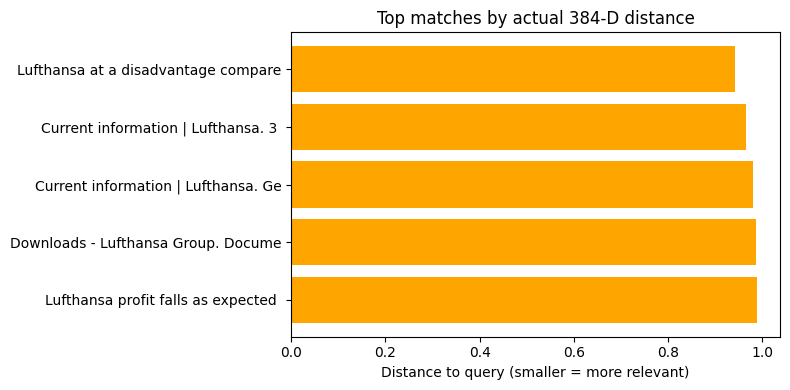

In [43]:
import matplotlib.pyplot as plt

results = collection.query(query_texts=["What are the biggest risks for Lufthansa?"], n_results=5)   # distances returned by default
docs  = [d[:35] for d in results["documents"][0]]
dists = results["distances"][0]

plt.figure(figsize=(8, 4))
plt.barh(docs, dists, color="orange")
plt.xlabel("Distance to query (smaller = more relevant)")
plt.title("Top matches by actual 384-D distance")
plt.gca().invert_yaxis()      # best match on top
plt.tight_layout(); plt.show()


d:\nihal\datacamp\ML practice\ml_env\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


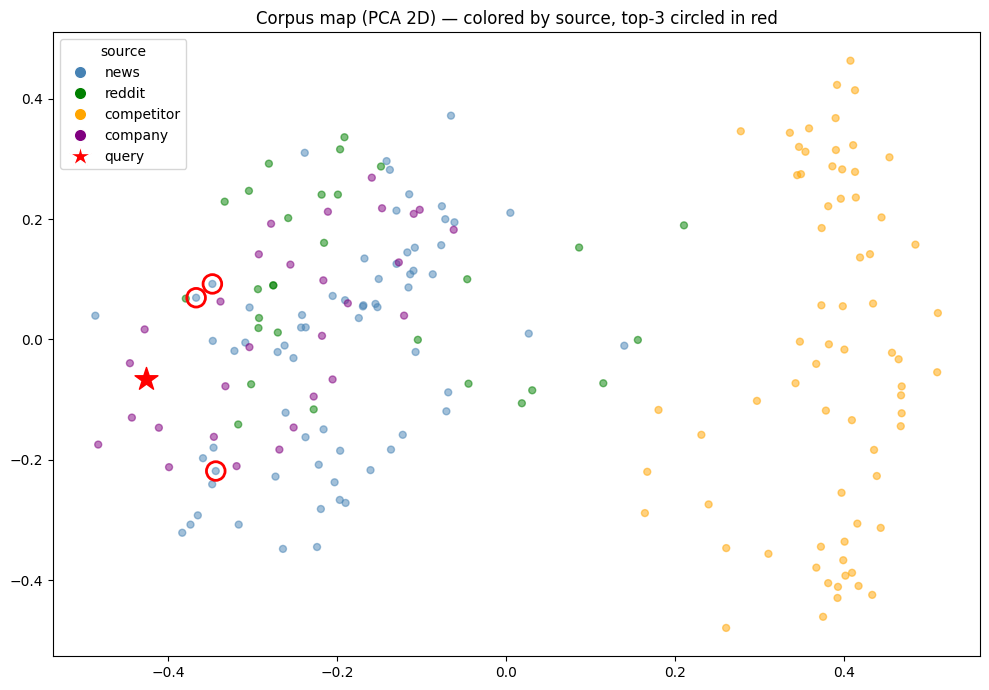

In [44]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np

query = "What are the biggest risks for Lufthansa?"

# 1. embed docs + query
model   = SentenceTransformer("all-MiniLM-L6-v2")
doc_emb = model.encode(texts)
q_emb   = model.encode([query])

# 2. squash 384 -> 2
coords = PCA(n_components=2).fit_transform(np.vstack([doc_emb, q_emb]))
doc_xy, q_xy = coords[:-1], coords[-1]

# 3. get the real top-3 from Chroma (ids = positions)
results = collection.query(query_texts=[query], n_results=3)
top_idx = [int(i) for i in results["ids"][0]]

# 4. color each doc by its source (aligned with texts via cleaned_docs)
cmap = {"news": "steelblue", "reddit": "green", "competitor": "orange", "company": "purple"}
pt_colors = [cmap[d["source"]] for d in cleaned_docs]

# 5. plot
plt.figure(figsize=(10, 7))
plt.scatter(doc_xy[:, 0], doc_xy[:, 1], c=pt_colors, s=25, alpha=0.5)                 # all docs
plt.scatter(doc_xy[top_idx, 0], doc_xy[top_idx, 1], s=180, facecolor="none",          # circle top-3
            edgecolor="red", linewidth=2, zorder=5)
plt.scatter(q_xy[0], q_xy[1], c="red", s=300, marker="*", zorder=6)                   # query

# custom legend (sources + query)
handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=9, label=s)
           for s, c in cmap.items()]
handles.append(Line2D([0], [0], marker="*", color="w", markerfacecolor="red", markersize=16, label="query"))
plt.legend(handles=handles, title="source")
plt.title("Corpus map (PCA 2D) — colored by source, top-3 circled in red")
plt.tight_layout(); plt.show()

In [45]:
%pip install rank_bm25

Note: you may need to restart the kernel to use updated packages.


In [46]:
from rank_bm25 import BM25Okapi

# tokenize each document (lowercase + split into words) — BM25 works on word lists
tokenized_corpus = [doc.lower().split() for doc in texts]

bm25 = BM25Okapi(tokenized_corpus)
print("BM25 index built over", len(tokenized_corpus), "docs")

BM25 index built over 195 docs


In [47]:
query = "Lufthansa A350 fleet order"

bm25_scores = bm25.get_scores(query.lower().split())

print(type(bm25_scores))
print(len(bm25_scores))
print(bm25_scores[:10])     # first 10 scores

<class 'numpy.ndarray'>
195
[1.67422593 1.61976543 1.46489857 1.22974508 1.89752391 1.76314799
 2.31956418 1.47575224 1.68841812 1.76314799]


In [48]:
doc_emb = model.encode(texts)      # 200 docs → 200 x 384, takes a few seconds

In [49]:
from sklearn.metrics.pairwise import cosine_similarity

q_emb = model.encode([query])                       # embed the query → 1 x 384
dense_scores = cosine_similarity(q_emb, doc_emb)[0] # compare query to all docs

print(type(dense_scores))
print(len(dense_scores))
print(dense_scores[:10])

<class 'numpy.ndarray'>
195
[0.46406078 0.37189868 0.322461   0.45282105 0.36518022 0.53181636
 0.4525612  0.40304762 0.39759248 0.4142366 ]


```python
bm25_scores[:5]   -> [1.41, 1.27, 1.67, 1.48, 1.55]   <- keyword, scale ~0 to 2
dense_scores[:5]  -> [0.38, 0.38, 0.32, 0.40, 0.39]   <- meaning, scale ~0 to 0.5
```

If we just added them, BM25's bigger numbers (1.4) would dominate the dense ones (0.4) — keyword would win unfairly. So first we put both on the same 0–1 scale.

In [50]:
import numpy as np

def normalize(x):
    x = np.array(x)
    return (x - x.min()) / (x.max() - x.min())

bm25_norm  = normalize(bm25_scores)
dense_norm = normalize(dense_scores)

print("bm25_norm  range:", bm25_norm.min(), "to", bm25_norm.max())
print("dense_norm range:", dense_norm.min(), "to", dense_norm.max())
print(bm25_norm[:5])
print(dense_norm[:5])

bm25_norm  range: 0.0 to 1.0
dense_norm range: 0.0 to 1.0
[0.28873709 0.27934483 0.25263648 0.2120819  0.32724707]
[0.56587523 0.42906713 0.35568035 0.5491907  0.41909406]


In [51]:
alpha = 0.5
combined = alpha * dense_norm + (1 - alpha) * bm25_norm

print(combined[:5])

[0.42730616 0.35420598 0.30415841 0.3806363  0.37317056]


```python
alpha = 0.5  →  50% semantic, 50% keyword   (equal trust)
alpha = 0.6  →  60% semantic, 40% keyword   (lean semantic)
alpha = 0.4  →  40% semantic, 60% keyword   (lean keyword)
```

# RANKING

In [ ]:
k = 5
top_idx = np.argsort(combined)[::-1][:k]

print(f"Top {k} HYBRID results:\n")
for rank, i in enumerate(top_idx, 1):
    print(f"#{rank}  score={combined[i]:.3f}  [{documents[i]['source']}]")
    print(f"     {texts[i][:120]}")
    print()

Top 5 HYBRID results:

#1  score=0.857  [news]
     Germany and Switzerland: Lufthansa Group Orders 20 New Airbus and Boeing Aircraft Worth 7.7 Billion Dollars to Boost Sus

#2  score=0.795  [news]
     Fleet Development - Lufthansa Group. With the new engine technology, . Lufthansa Group ordered 59 state-of-the-art long-

#3  score=0.785  [news]
     Lufthansa modernizes its fleet with these long-haul aircraft - The Manual. December 27, 2024 - Lufthansa Group announced

#4  score=0.767  [news]
     Lufthansa fleet - Wikipedia. 5 days ago - The mainline fleet is composed of seven different aircraft families: the Airbu

#5  score=0.746  [competitor]
     Emirates secures future of fleet with record-breaking Boeing order. The new order expands Emirates' Boeing orderbook to 



In [53]:
# Pure SEMANTIC ranking (dense only, no BM25)
sem_idx = np.argsort(dense_scores)[::-1][:5]

print("=== PURE SEMANTIC (meaning only) ===\n")
for rank, i in enumerate(sem_idx, 1):
    print(f"#{rank}  {texts[i][:90]}")

print("\n=== HYBRID (meaning + keyword) ===\n")
for rank, i in enumerate(top_idx, 1):
    print(f"#{rank}  {texts[i][:90]}")

=== PURE SEMANTIC (meaning only) ===

#1  Lufthansa modernizes its fleet with these long-haul aircraft - The Manual. December 27, 20
#2  Fleet Development - Lufthansa Group. With the new engine technology, . Lufthansa Group ord
#3  Lufthansa Group purchases further latest-generation long-haul aircraft. December 20, 2024 
#4  Fleet. In the 2023 financial year, the Lufthansa Group expanded its existing aircraft orde
#5  Lufthansa - Wikipedia. 1 week ago - In March 2019, Lufthansa ordered 20 Boeing 787-9 and a

=== HYBRID (meaning + keyword) ===

#1  Germany and Switzerland: Lufthansa Group Orders 20 New Airbus and Boeing Aircraft Worth 7.
#2  Fleet Development - Lufthansa Group. With the new engine technology, . Lufthansa Group ord
#3  Lufthansa modernizes its fleet with these long-haul aircraft - The Manual. December 27, 20
#4  Lufthansa fleet - Wikipedia. 5 days ago - The mainline fleet is composed of seven differen
#5  Emirates secures future of fleet with record-breaking Boeing order

In [57]:
def hybrid_search(query, k=5, alpha=0.5):
    # Step 1 — keyword scores
    bm25_scores  = bm25.get_scores(query.lower().split())

    # Step 2 — semantic scores
    q_emb        = model.encode([query])
    dense_scores = cosine_similarity(q_emb, doc_emb)[0]

    # Step 3 — normalize both, then combine
    bm25_norm  = normalize(bm25_scores)
    dense_norm = normalize(dense_scores)
    combined   = alpha * dense_norm + (1 - alpha) * bm25_norm

    # Step 4 — rank and return top-k
    top_idx = np.argsort(combined)[::-1][:k]
    return [
        {"text": texts[i], "score": round(float(combined[i]), 3),
         "source": documents[i]["source"], "url": documents[i]["url"]}
        for i in top_idx
    ]

In [58]:
for r in hybrid_search("Lufthansa A350 fleet order"):
    print(r["score"], "|", r["source"], "|", r["text"][:80])

0.857 | news | Germany and Switzerland: Lufthansa Group Orders 20 New Airbus and Boeing Aircraf
0.795 | news | Fleet Development - Lufthansa Group. With the new engine technology, . Lufthansa
0.785 | news | Lufthansa modernizes its fleet with these long-haul aircraft - The Manual. Decem
0.767 | news | Lufthansa fleet - Wikipedia. 5 days ago - The mainline fleet is composed of seve
0.746 | competitor | Emirates secures future of fleet with record-breaking Boeing order. The new orde
